<a href="https://colab.research.google.com/github/VioletLiu0620/deeplearning/blob/main/notes/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch workflow

Let's explore an example PyTorch end-to-end workflow

In [ ]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making prediction s and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making prediction s and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn # nn contains all of the pytorch building blocks
import matplotlib.pyplot as plt

### 1. Data Prepairing and loading

Data can be almost anything... in machine learning.
* Excel spreadsheet
* Images of any kinds
* Videos
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model  to learn patterns in that numerical representations

To showcase this, let's create some *known* data using the linear regression formula

We'll use a linear regression formula to make a straight line with known **parameters**.

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # change from size=(50) to size=(50,1), so you have one coloumn as the feature, add an extra sqaure bracket, add a dimension
y = weight * X + bias # y = mx + b,

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Spliting data into training and test sets

Training set, Validatation set, testing set

In [ ]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

how might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize! x3"

In [ ]:
def plot_predictions(train_data=X_train,
                     train_label=y_train,
                     test_data=X_test,
                     test_label=y_test,
                     predictions= None):

  """
  Plots training data, test data and compares predictions
  """

  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_label, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_label, c="g", s=4, label= "Testing data")

  # Are there predictions
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":14});

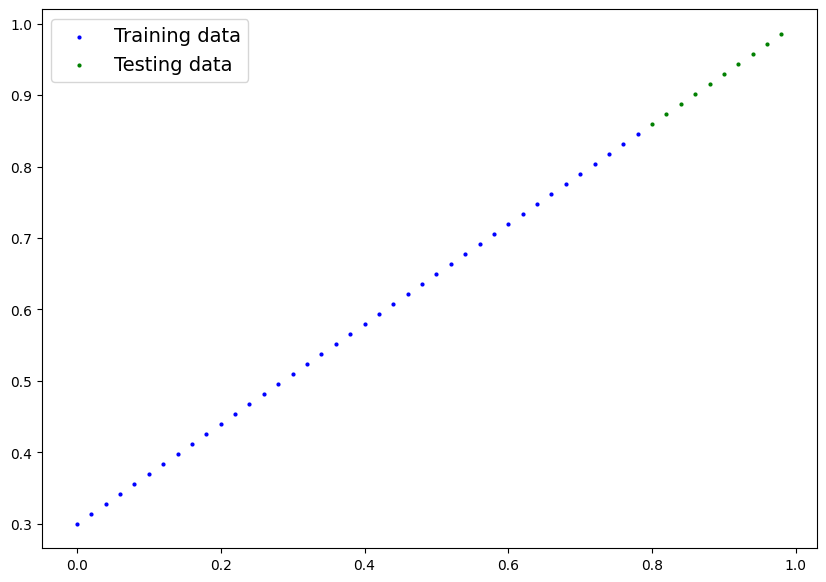

In [ ]:
plot_predictions();

## 2. Build model

Our first PyTorch model!

What our model does:
1. start with random value (weight and bias)
2. look at training data and adjust the random values to better represent (or get closer to) the ideal values so the weight and bias values we used to create the data

How does it do so?

Through 2 main algorithms:
1. Gradient descent
2. Backpropagation

In [ ]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in pytorch inherhits from nn.module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, # This is default to be True
                                            dtype=torch.float32))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True, # can this be updated via gradeint decsent?
                                         dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias # linear regression formula


### Pytorch model building essentials

* torch.nn - contains all of the buidling for computations graphs (a neural networds can be considered a computational graphs)
* torch.nn.Parameters - what parametes shoudl our model try and learn, often a pytorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you ubclass it, you should overwrite forward()
* torch.optim - this where the optimizers in pytorch live, they will help with gradietn descent
* def forward() - All nn.Module subclassess require you to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of our pyTorch model

Now we've created a model, let's see what's inside...

So we can check our model paramters or what's inside our model using `parameters()`



In [ ]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named paramters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how wel it predicts `y_test` based on `X_test`

When we pass data through our model, it is going to run the forward() method

In [ ]:
# Make predictions with model
with torch.inference_mode(): # inference mode turn off gradient tracking
  y_preds = model_0(X_test)

# inference_mode() is prefered, but no_grad() do simialr thing and output similar resutls
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds, y_test

(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

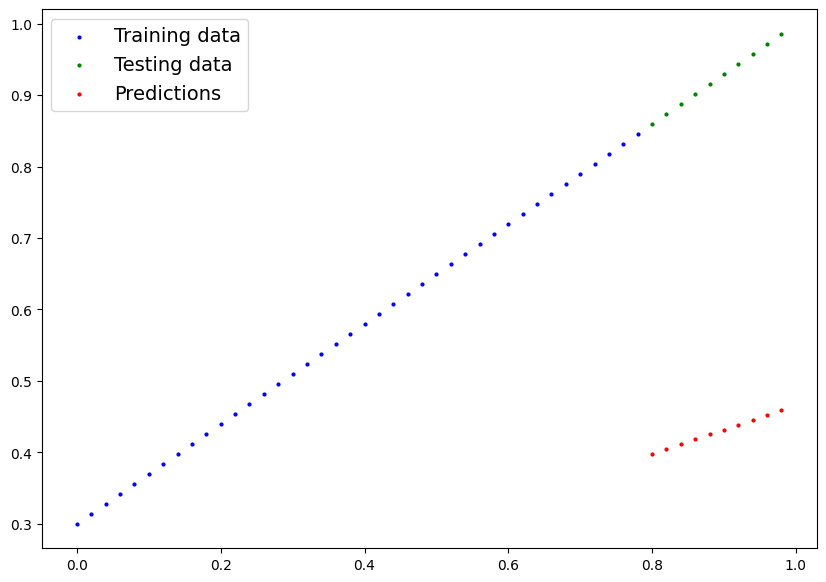

In [ ]:
plot_predictions(predictions=y_preds)

## 3. Training model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

or in other words from a poor representation of the data to a better representawtion of the data

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss fucntion may also be called cost fucntion or criterion in different areas. We use loss function here.

Thing we need to train:

* **Loss fucntion:** A function to measure how wrong your model's predictions are to the ideal output, lower is better
* **Optimizers:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to imporve the loss function.

  Inside the optimizer, you will need to set two parameters:

  * `params` - the model parameters you'd like to optimize, for example `params=model_0.parameters()`
  * `lr` (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimzkier changes the parameters with each step (a small `lr` results in small cahnges, etc)

and specfically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Setup a loss fucntion
# Mean absolute error (MAE)
loss_fn = nn.L1Loss()

# Setup an optimzier
# SGD stochastic gradient decsent

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr= 0.01) #lr = learning rate = possibly the most important hyperparameter you can set5

for a classficiation problem, might need another loss function like `nn.BCELOss()` (binary cross entropy loss)

### Building a training loop and a testing loop in pytorch

A couple of things we need in a training loop:

0. Loop through the data
1. forward pass (this involves data moving through our model's `forward()` function) - to make prediction on data also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the paramters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

Gradient is the changes in x and change in y, slope, gradient is the best when it's 0 for simple cases (meaning the difference between the random data and the correct data is small)

Think of a hill

you try to minimize the gradient

In [ ]:
with torch.no_grad():
  print(list(model_0.parameters()))



[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [ ]:
# An epoch is one loop thorugh the data... (this is a hyperparameter because we've set it)
epochs = 200

# Track differences values
epoch_count = []
loss_values = []
test_loss_values =[]

### Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # train mode in PyTorch set all parameters that requires requires_grad() = True

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train) # output = loss(input, target)
  #print(f"Loss: {loss}")
  # 3. Optimzer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect tot he parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default how the optimizer changes will acculumate through the loop... we have to ero them above in step 3 forward

  ### Testing
  model_0.eval() # turn off different settings in the model not needed for evaluation/testing

  with torch.inference_mode(): # turns off gradient tracking and a couple more things behind
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred,y_test)
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Loss: {loss}, Test_Loss: {test_loss} Weight: {model_0.weights.data}, Bias: {model_0.bias.data}")


Loss: 0.31288138031959534, Test_Loss: 0.48106518387794495 Weight: tensor([0.3406]), Bias: tensor([0.1388])
Loss: 0.1976713240146637, Test_Loss: 0.3463551998138428 Weight: tensor([0.3796]), Bias: tensor([0.2388])
Loss: 0.08908725529909134, Test_Loss: 0.21729660034179688 Weight: tensor([0.4184]), Bias: tensor([0.3333])
Loss: 0.053148526698350906, Test_Loss: 0.14464017748832703 Weight: tensor([0.4512]), Bias: tensor([0.3768])
Loss: 0.04543796554207802, Test_Loss: 0.11360953003168106 Weight: tensor([0.4748]), Bias: tensor([0.3868])
Loss: 0.04167863354086876, Test_Loss: 0.09919948130846024 Weight: tensor([0.4938]), Bias: tensor([0.3843])
Loss: 0.03818932920694351, Test_Loss: 0.08886633068323135 Weight: tensor([0.5116]), Bias: tensor([0.3788])
Loss: 0.03476089984178543, Test_Loss: 0.0805937647819519 Weight: tensor([0.5288]), Bias: tensor([0.3718])
Loss: 0.03132382780313492, Test_Loss: 0.07232122868299484 Weight: tensor([0.5459]), Bias: tensor([0.3648])
Loss: 0.02788739837706089, Test_Loss: 0

In [ ]:
import numpy as np
np.array(torch.tensor(loss_values).numpy())

array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

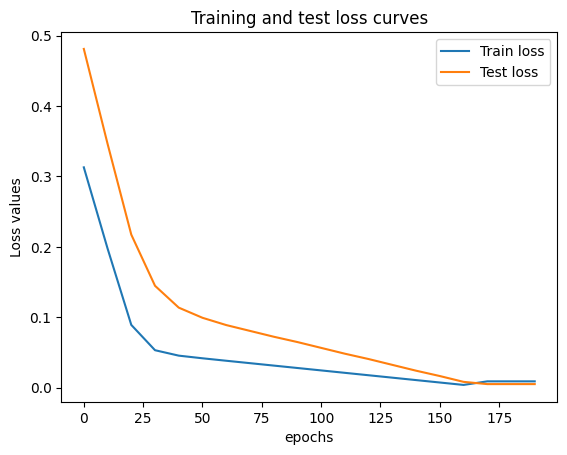

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = "Train loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Training and test loss curves")
plt.xlabel("epochs")
plt.ylabel("Loss values")
plt.legend()

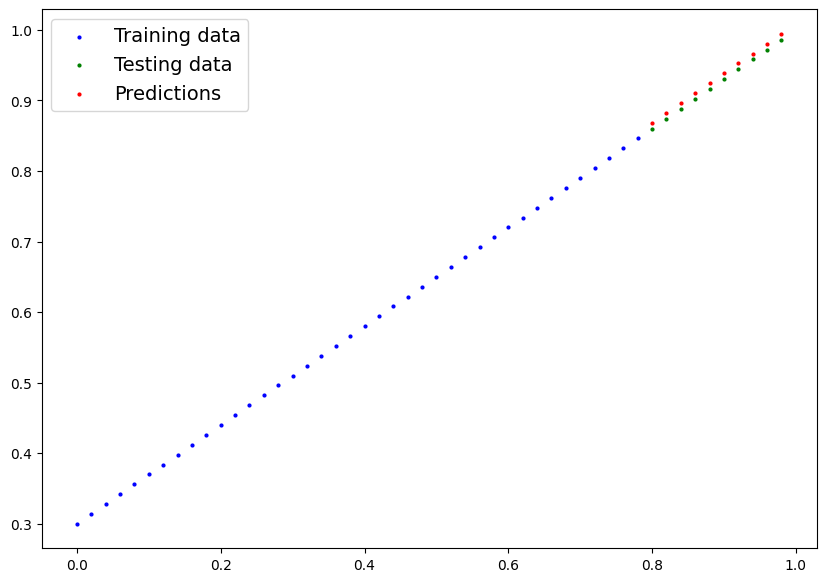

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

plot_predictions(predictions= y_preds_new)

## Saving a model in PyTorch

There are three main methods you can pick to save the model

1. `torch.save()` - allows you save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [ ]:
# Saving our pytorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents= True, exist_ok= True)

# 2. Create model_save_path
MODEL_NAME = "01_pytorch_workflow_model_0.pth" # common convention for saving a pytorch model
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME # because we import torch

# 3. Save the model state dict
print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Jul  7 13:04 01_pytorch_workflow_model_0.pth


## Loading a pytorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model calssa nd load the saved `state_dict()` into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# To load in a saved state_dcit we ahve to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model 0, this iwll update the new instance with updated parameters
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# Make some model preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

In [ ]:
# Compare loaded model pres with original model preds

y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

In [ ]:
# import pytorch and matplot
import torch
from torch import nn
import matplotlib.pyplot as plt

Create device-agonoastic code.

This means if we've got access to a CPU, our code will use it for potentially faster computing.

If no CPU is available, the code will default to using CPU.

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 6.1 Data

In [ ]:
# Create some data using the linear regression formula of y = w * x + bias

weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create the x and y (features and labels)
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

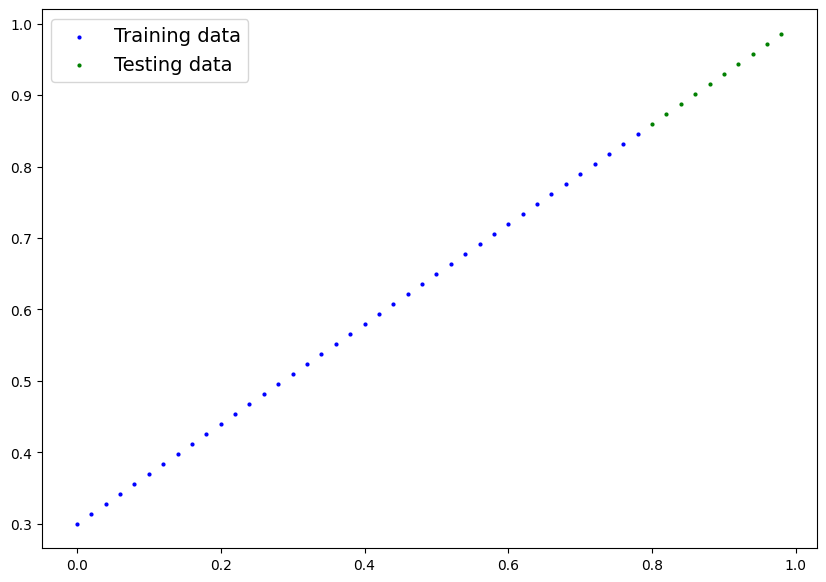

In [ ]:
# Plot the data
# Note if you don't have the plot_prediction()fucntion laoded, this will error
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 Building a PyTorch linear model

In [ ]:
# Create a linear model by subclassing nn.Module

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters / also called: linear transform, porbing layer, fully connected layer, dense layer
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check the model current devcie
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training

For training we need:
- a loss function
- optimizer
- training loop
- testing loop

In [ ]:
# Setup the loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer
optimizer = torch.optim.SGD(params= model_1.parameters(),
                            lr=0.01)

In [ ]:
# training loop
torch.manual_seed(42)

epochs = 200

# Put data on the target device (device agnostic code on data)
# Everything including model and data need to be on the same device

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):

  model_1.train()

  y_preds = model_1(X_train)

  loss = loss_fn(y_preds, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing

  model_1.eval() # turn off some backstage calculating

  with torch.inference_mode(): # turn off gradient tracking
    test_pred = model_1(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}, Test_loss: {test_loss}")

Epoch: 0, Loss: 0.5551779270172119, Test_loss: 0.5739762187004089
Epoch: 10, Loss: 0.4399681091308594, Test_loss: 0.4392664134502411
Epoch: 20, Loss: 0.3247582018375397, Test_loss: 0.30455657839775085
Epoch: 30, Loss: 0.20954833924770355, Test_loss: 0.16984669864177704
Epoch: 40, Loss: 0.09433844685554504, Test_loss: 0.03513690456748009
Epoch: 50, Loss: 0.023886388167738914, Test_loss: 0.04784907028079033
Epoch: 60, Loss: 0.019956795498728752, Test_loss: 0.045803118497133255
Epoch: 70, Loss: 0.016517987474799156, Test_loss: 0.037530567497015
Epoch: 80, Loss: 0.013089174404740334, Test_loss: 0.02994490973651409
Epoch: 90, Loss: 0.009653178043663502, Test_loss: 0.02167237363755703
Epoch: 100, Loss: 0.006215683650225401, Test_loss: 0.014086711220443249
Epoch: 110, Loss: 0.00278724217787385, Test_loss: 0.005814164876937866
Epoch: 120, Loss: 0.0012645035749301314, Test_loss: 0.013801801018416882
Epoch: 130, Loss: 0.0012645035749301314, Test_loss: 0.013801801018416882
Epoch: 140, Loss: 0.001

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
weight, bias

(0.7, 0.3)

### 6.4 Making and evaluating predictions

In [ ]:
# Turn the model into the evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

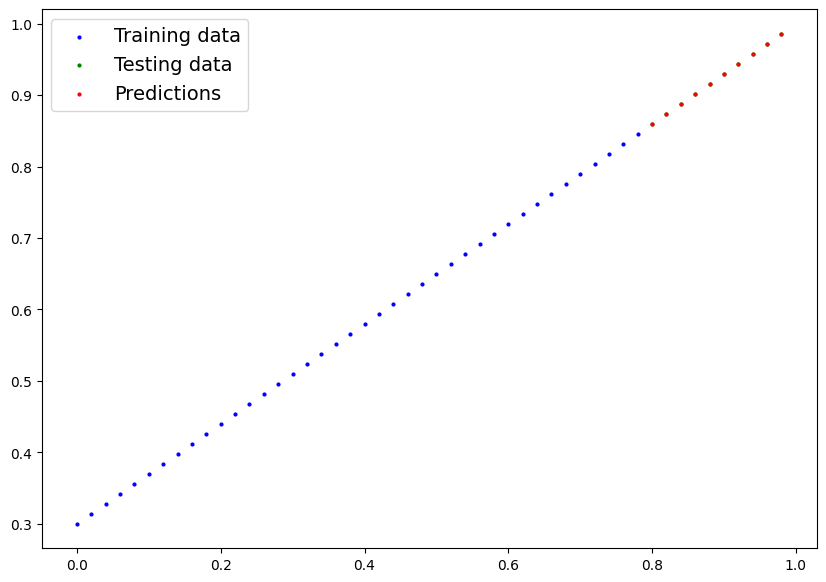

In [ ]:
plot_predictions(predictions= y_preds.cpu())

### 6.5 Saving and Loading a trained model

In [ ]:
from pathlib import Path

# 1. Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents= True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f= MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
# Load a PyTorch

# Create a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the save model 1 state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the laoded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
# Evaluating the loaded model
loaded_model_1.eval()
with torch.inference_mode():
  y_preds_1 = loaded_model_1(X_test)

y_preds == y_preds_1

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')